In [40]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import sys

main_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if main_dir not in sys.path:
    sys.path.insert(0, main_dir)

from utils import plot_loss_curves

**1. Importing Data**

As in the PyTorch script, the Fashion-MNIST dataset will also be used in this implementation.

In [41]:
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)

It is worth noting that TensorFlow automatically handles GPU acceleration without requiring manual device placement.

**2. Exploratory Data Analysis**

In [42]:
print(f"The length of train dataset: {len(x_train)}")
print(f"The length of train dataset: {len(y_train)}")
print(f"The length of train dataset: {len(x_test)}")
print(f"The length of train dataset: {len(y_test)}")

The length of train dataset: 60000
The length of train dataset: 60000
The length of train dataset: 10000
The length of train dataset: 10000


In [43]:
image = x_train[0]
image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

The input features consist of matrix values ranging from 0 to 255.

In [44]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


Since the dataset contains 10 distinct classes, this is a multi-class classification problem.

In [45]:
print(f"The shape of image is: {image.shape}")

The shape of image is: (28, 28)


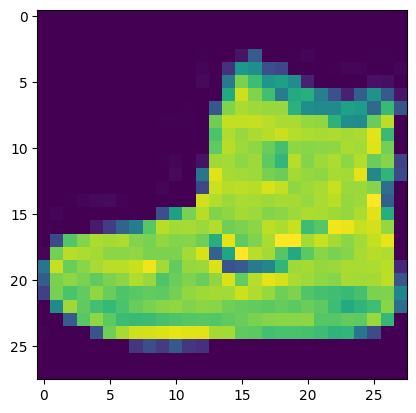

In [46]:
plt.imshow(image)

**3. Preprocessing Data**

3.1 Normalize dataset

Data normalization was applied to accelerate model convergence and improve overall classification accuracy.

In [47]:
x_train = x_train / 255.0
x_test = x_test / 255.0 

3.2 Add channel dimension

In [48]:
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

The input data was reshaped to include a channel dimension, satisfying TensorFlow's 4D tensor requirement [batch_size, height, width, channels] for CNNs. Adding tf.newaxis explicitly tells TensorFlow: "This is a 2D image with 1 color channel."

**4. Building model**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

**5. Training model**

In [50]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 67s 38ms/step - accuracy: 0.7670 - loss: 0.6409 - val_accuracy: 0.8603 - val_loss: 0.3711
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.8827 - loss: 0.3188 - val_accuracy: 0.8923 - val_loss: 0.2946
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9017 - loss: 0.2673 - val_accuracy: 0.8977 - val_loss: 0.2759
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - accuracy: 0.9147 - loss: 0.2278 - val_accuracy: 0.9002 - val_loss: 0.2648
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9265 - loss: 0.2004 - val_accuracy: 0.9063 - val_loss: 0.2503


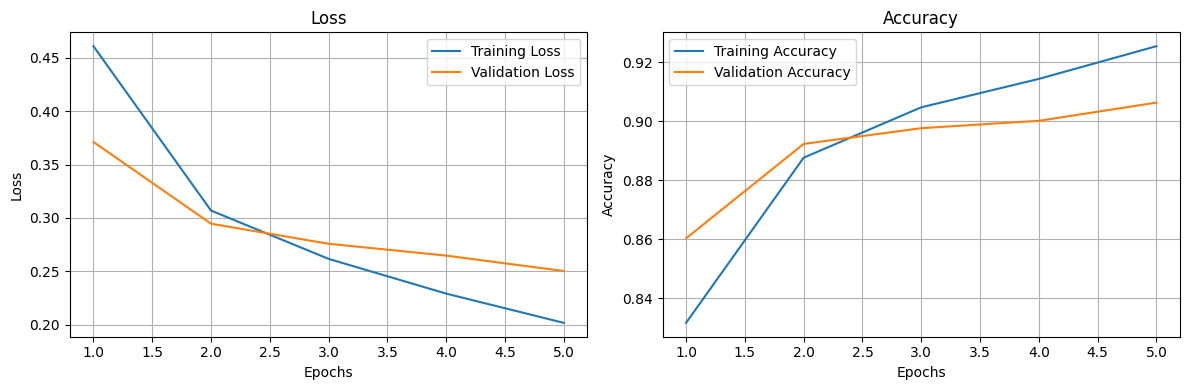

In [51]:
plot_loss_curves(history)

**6. Evaluate**

In [52]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print(f"Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9011 - loss: 0.2713
Test Accuracy: 90.08%


**7. Saving model**

In [53]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "tensorflow_computer_vision_model.weights.h5"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
model.save_weights(str(MODEL_SAVE_PATH))

Saving model to: models\tensorflow_computer_vision_model.weights.h5
